In [2]:
pip install stop_words

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 2.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from pathlib import Path
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import MaxAbsScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from stop_words import get_stop_words
import matplotlib.pyplot as plt
from scipy.stats import entropy
import re
from nltk.corpus import stopwords
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from tqdm import tqdm

from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments
)

In [4]:
from datasets import load_dataset

dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df = dataset["train"].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

In [5]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

df["text"] = df["subject"] + " " + df["body"]

In [6]:
train_idx = np.loadtxt("train_idx.txt", dtype=int)
val_idx = np.loadtxt("val_idx.txt", dtype=int)
test_idx = np.loadtxt("test_idx.txt", dtype=int)

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]
test_df = df.iloc[test_idx]

# EDA

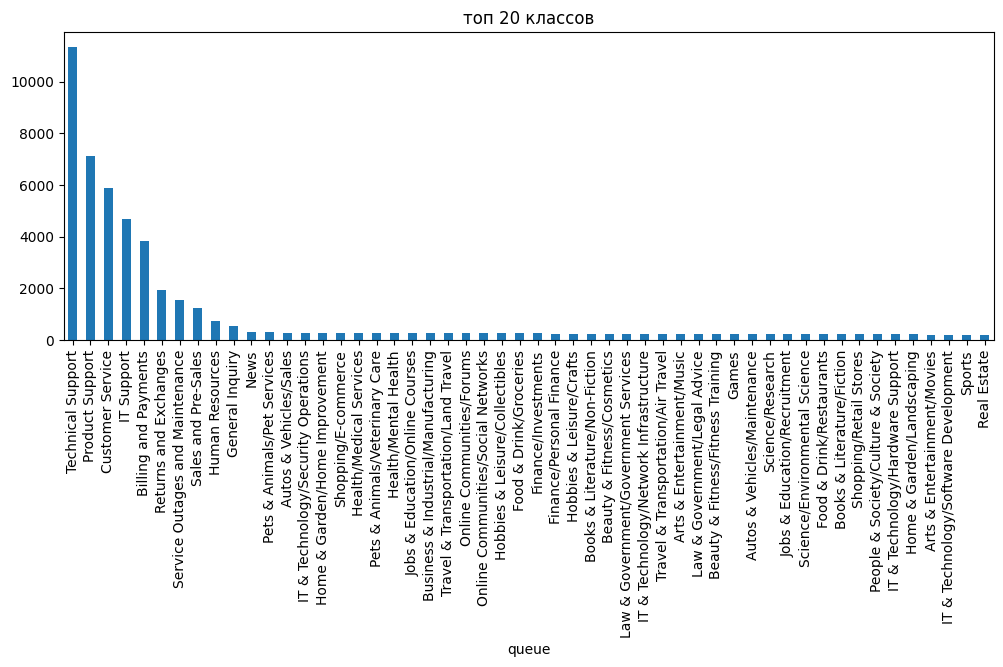

In [7]:
train_df["queue"].value_counts().plot(kind="bar", figsize=(12,4))
plt.title("топ 20 классов")
plt.show()

In [8]:
train_df["queue"].value_counts().head(10)

,count
queue,
Technical Support,11354
Product Support,7139
Customer Service,5905
IT Support,4673
Billing and Payments,3853
Returns and Exchanges,1956
Service Outages and Maintenance,1534
Sales and Pre-Sales,1228
Human Resources,730


In [9]:
train_df["len"] = train_df["text"].str.len()
train_df["len"].describe()

/tmp/ipykernel_2412/996778237.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["len"] = train_df["text"].str.len()


,len
count,49412.000000
mean,463.754635
std,226.844163
min,5.000000
25%,279.000000
50%,459.000000
75%,633.000000
max,2284.000000


/tmp/ipykernel_2412/252572459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["text"] = train_df["text"].fillna("")
/tmp/ipykernel_2412/252572459.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["length"] = train_df["text"].apply(len)


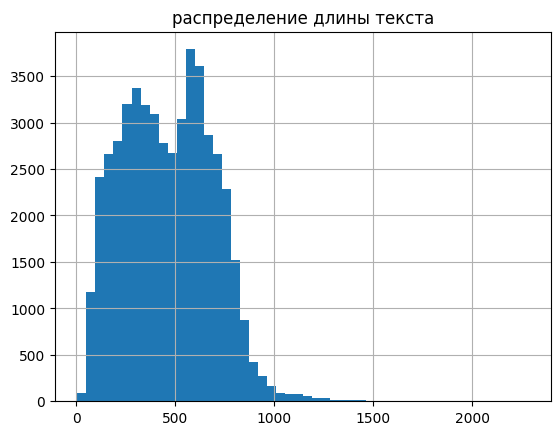

In [10]:
train_df["text"] = train_df["text"].fillna("")

train_df["length"] = train_df["text"].apply(len)

train_df["length"].hist(bins=50)
plt.title("распределение длины текста")
plt.show()

Средняя длина текстов — 464 знака. Из-за двух пиков (300 и 600 зн.) и большого объема нужно убрать записи короче 4 символов и увеличить max_features (30 слов мало).

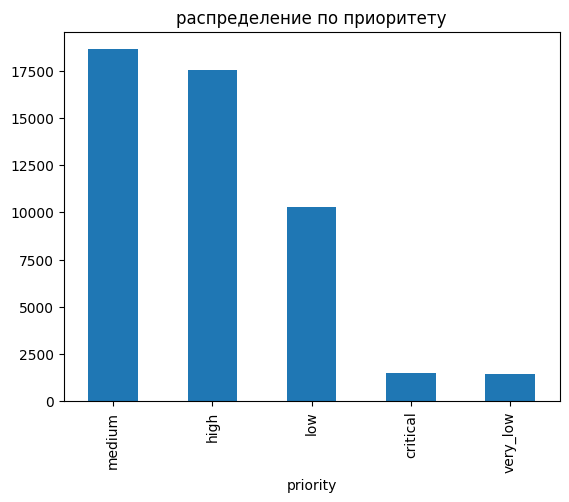

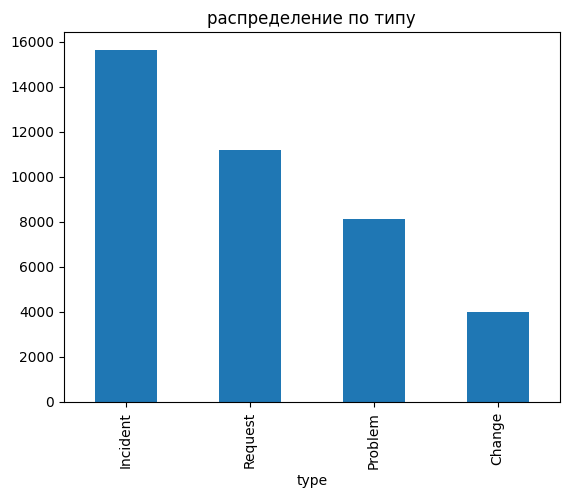

In [11]:
train_df["priority"].value_counts().plot(kind="bar")
plt.title("распределение по приоритету")
plt.show()

train_df["type"].value_counts().plot(kind="bar")
plt.title("распределение по типу")
plt.show()

По всем категориям явно виден дисбаланс.

In [12]:
train_df.groupby("queue")["len"].mean().sort_values().tail(10)

,len
queue,
IT & Technology/Software Development,602.160194
Travel & Transportation/Air Travel,603.133603
Law & Government/Government Services,603.344000
Online Communities/Forums,604.200743
Science/Research,606.827004
Pets & Animals/Veterinary Care,609.435252
Online Communities/Social Networks,613.348485
Home & Garden/Landscaping,613.552995
Arts & Entertainment/Movies,627.251208


In [13]:
train_df.groupby("priority")["len"].mean()

,len
priority,
critical,590.850923
high,449.210019
low,466.567802
medium,457.453594
very_low,568.532269


In [14]:
train_df.groupby("type")["len"].mean()

,len
type,
Change,476.570430
Incident,418.955796
Problem,415.467234
Request,443.945902


Длинные тексты (до 590 знаков) пишут либо в критических ситуациях, либо в низкоприоритетных (идеи/фидбек). Рутина кратка, а сложные бытовые темы (медицина, покупки) — развернуты.

In [15]:
train_dist = train_df["queue"].value_counts(normalize=True)
val_dist   = val_df["queue"].value_counts(normalize=True)
test_dist  = test_df["queue"].value_counts(normalize=True)

dist_df = pd.concat([train_dist, val_dist, test_dist], axis=1)
dist_df.columns = ["train", "val", "test"]

dist_df.fillna(0).head()

,train,val,test
queue,,,
Technical Support,0.229782,0.228951,0.229561
Product Support,0.144479,0.143135,0.151692
Customer Service,0.119505,0.121276,0.124008
IT Support,0.094572,0.086949,0.083374
Billing and Payments,0.077977,0.079177,0.086126


нет значимых различий и смещений по трейну/тесту/валидации

In [16]:
train_df.groupby('language')['queue'].count()

,queue
language,
de,26799
en,22613


In [17]:
pd.crosstab(train_df["queue"], train_df["language"]).head(20)

language,de,en
queue,,
Arts & Entertainment/Movies,207,0
Arts & Entertainment/Music,243,0
Autos & Vehicles/Maintenance,237,0
Autos & Vehicles/Sales,287,0
Beauty & Fitness/Cosmetics,250,0
Beauty & Fitness/Fitness Training,240,0
Billing and Payments,1550,2303
Books & Literature/Fiction,232,0
Books & Literature/Non-Fiction,252,0


датасет содержит два языка: английский и немецкий. имеем достаточно много групп, где есть только немецкий язык и нет английского


#BASELINE модель

энкодер

In [18]:
le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

df["queue_id"] = le_queue.fit_transform(df["queue"])
df["priority_id"] = le_priority.fit_transform(df["priority"])
df["type_id"] = le_type.fit_transform(df["type"])


from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

print(len(train_df), len(val_df), len(test_df))

50029 5559 6177


In [19]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])

In [21]:
clf = LogisticRegression(max_iter=200)

clf.fit(X_train, train_df["queue_id"])

pred = clf.predict(X_test)

macro_f1 = f1_score(test_df["queue_id"], pred, average="macro")
acc = accuracy_score(test_df["queue_id"], pred)

print("Baseline MacroF1:", macro_f1)
print("Baseline Accuracy:", acc)

convergence after 21 epochs took 36 seconds
Baseline MacroF1: 0.704215625442781
Baseline Accuracy: 0.5774647887323944


# Multitask Transformer

In [22]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [23]:
class TicketDataset(Dataset):

    def __init__(self, df):
        self.texts = df["text"].tolist()
        self.queue = df["queue_id"].tolist()
        self.priority = df["priority_id"].tolist()
        self.type = df["type_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )

        item = {k:v.squeeze() for k,v in enc.items()}

        item["queue_labels"] = torch.tensor(self.queue[idx])
        item["priority_labels"] = torch.tensor(self.priority[idx])
        item["type_labels"] = torch.tensor(self.type[idx])

        return item

In [24]:
class MultiTaskModel(nn.Module):

    def __init__(self, model_name, n_queue, n_priority, n_type):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)

        hidden = self.encoder.config.hidden_size

        self.queue_head = nn.Linear(hidden, n_queue)
        self.priority_head = nn.Linear(hidden, n_priority)
        self.type_head = nn.Linear(hidden, n_type)

    def forward(
        self,
        input_ids,
        attention_mask,
        queue_labels=None,
        priority_labels=None,
        type_labels=None
    ):

        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = out.last_hidden_state[:,0]

        queue_logits = self.queue_head(cls)
        priority_logits = self.priority_head(cls)
        type_logits = self.type_head(cls)

        loss = None

        if queue_labels is not None:

            ce = nn.CrossEntropyLoss()

            loss = (
                ce(queue_logits, queue_labels)
                + ce(priority_logits, priority_labels)
                + ce(type_logits, type_labels)
            )

        return {
            "loss": loss,
            "queue_logits": queue_logits,
            "priority_logits": priority_logits,
            "type_logits": type_logits
        }

In [25]:
train_ds = TicketDataset(train_df)
val_ds = TicketDataset(val_df)
test_ds = TicketDataset(test_df)

In [26]:
model = MultiTaskModel(
    model_name,
    n_queue=len(le_queue.classes_),
    n_priority=len(le_priority.classes_),
    n_type=len(le_type.classes_)
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
import torch

print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [32]:
training_args = TrainingArguments(
    output_dir="./model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    fp16=True,
    logging_steps=200,
    save_strategy="no",
)

In [33]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

In [34]:
trainer.train()

pred = trainer.predict(test_ds)

Step,Training Loss
200,4.039235
400,3.858929
600,3.718956
800,3.637718
1000,3.541934
1200,3.482943
1400,3.426923
1600,3.366957
1800,3.289461
2000,3.264838


#МЕТРИКИ

In [35]:
queue_logits = pred.predictions[0]
priority_logits = pred.predictions[1]
type_logits = pred.predictions[2]

queue_pred = queue_logits.argmax(axis=1)
priority_pred = priority_logits.argmax(axis=1)
type_pred = type_logits.argmax(axis=1)

macro_f1 = f1_score(test_df["queue_id"], queue_pred, average="macro")

acc_queue = accuracy_score(test_df["queue_id"], queue_pred)
acc_priority = accuracy_score(test_df["priority_id"], priority_pred)
acc_type = accuracy_score(test_df["type_id"], type_pred)

print("MacroF1 queue:", macro_f1)
print("Acc queue:", acc_queue)
print("Acc priority:", acc_priority)
print("Acc type:", acc_type)

MacroF1 queue: 0.4155139885179212
Acc queue: 0.434191355026712
Acc priority: 0.5434677027683341
Acc type: 0.8484701311316173


# Итоговый скор

In [36]:
score = (
    0.70 * macro_f1
    + 0.15 * acc_priority
    + 0.15 * acc_type
)

print("Final Score:", score)

Final Score: 0.49965046704753746


Узнал, что дедлайн в 12:00, а не в 23:59 за час до дедлайна, поэтому пришлось порезать модель, чтобы успеть обучить. Виноват ((((

# метрика confidence

In [37]:
probs = torch.softmax(torch.tensor(queue_logits), dim=1)

confidence = probs.max(dim=1).values.numpy()
preds = probs.argmax(dim=1).numpy()

res = pd.DataFrame({
    "true": test_df["queue_id"].values,
    "pred": preds,
    "conf": confidence
})

при разных confidence

In [38]:
thresholds = np.linspace(0.1,0.9,9)

for t in thresholds:

    sub = res[res.conf >= t]

    if len(sub) == 0:
        continue

    f1 = f1_score(sub.true, sub.pred, average="macro")

    print(f"threshold={t:.2f} size={len(sub)} macroF1={f1:.3f}")

threshold=0.10 size=5468 macroF1=0.499
threshold=0.20 size=5152 macroF1=0.509
threshold=0.30 size=3580 macroF1=0.605
threshold=0.40 size=2145 macroF1=0.599
threshold=0.50 size=902 macroF1=0.555
threshold=0.60 size=429 macroF1=0.659
threshold=0.70 size=375 macroF1=0.706
threshold=0.80 size=335 macroF1=0.659
threshold=0.90 size=249 macroF1=0.666
